# Rapid non-destructive phenotyping of stomatal traits — Wheat 400× minimal pipeline

Reproduction of: Pathoumthong, P., Zhang, Z., Roy, S.J. & El Habti, A. **Rapid non-destructive method to phenotype stomatal traits.** *Plant Methods* 19, 36 (2023). https://doi.org/10.1186/s13007-023-01016-y (bioRxiv 2022.06.28.497692)

Author materials used (pinned):
- Code: `github.com/rapidmethodstomata/rapidmethodstomata` @ commit `a8ff03832b9e03b03c55c1ff3a08f7244f8a1e85` (Detection_withcsv.ipynb, Bounding_box_extraction.ipynb)
- Author Colab scripts from the public Drive folder: **Wheat Detection (400×)** and **Wheat Measurement (400×)**
- Models & sample: public Google Drive folder `1Bta3MITvtJlY0yTmUauX1ayT2Wy3IWm2` (Wheat): `Wheat_detection_400x.pt.pt`, `Wheat_measurement.pth`, sample image `Wheat_Scepter_2_8_W_Ad_X400_20210923.jpg`

**Scope (one example, partial demonstration):** run the author's three-step Wheat 400× pipeline — YOLOv5 stomata detection → bounding-box extraction → Detectron2 Mask R-CNN measurement — on **one** 400× handheld-microscope image, and report stomata count plus per-stoma area in pixels.

**Execution status:** executed in Colab (see saved outputs). This single-image run does **not** reproduce the paper's dataset-level accuracy statistics; it exercises the released inference pipeline only.

**AI-assisted adaptation notice (EN/JP):** the scientific operations (detection command, `ExtractBBox`, measurement config/loop) are copied from the authors' scripts; the Drive download, pinned installs, path/device handling and plots are AI-generated glue. / 本ノートブックの科学的操作は著者公開スクリプトのコピー、ダウンロード・インストール・可視化部分はAI生成の補助コードです。著者本人によるColab実装ではありません。

**日本語要約:** 本ノートブックは、ProScope HR2/HR5 ハンドヘルド顕微鏡画像(コムギ 400倍)に対し、(1) YOLOv5による気孔検出、(2) 検出枠からの個体切り出し、(3) Detectron2 Mask R-CNNによる面積測定、を実行します。論文の完全な再現ではなく、公開された推論パイプラインの最小例です。

## Runtime selection / ランタイム選択

This notebook runs on **CPU or GPU (T4)**. The models are small; a single image is fast on either. Select `Runtime > Change runtime type` → CPU or T4 GPU, then **Run all**.
/ CPU でも T4 GPU でも動作します(推奨: T4)。`ランタイム > ランタイムのタイプを変更` から選択し、**すべてのセルを実行**してください。

Expected: dependency setup ~5–15 min (Detectron2 build dominates), downloads < 500 MB, analysis < 5 min. Free-tier availability may differ. / セットアップ約5〜15分、ダウンロード0.5GB未満、解析は数分です。

In [ ]:
import torch, sys, platform
print("Python", sys.version.split()[0])
print("torch", torch.__version__)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU (scientifically equivalent for this single-image demo; slower).")
print("Selected device:", DEVICE)

Python 3.13.15
torch 2.11.0+cu130
GPU: Tesla T4
Selected device: cuda


## 1. Detection model: clone the pinned YOLOv5

The authors cloned `ultralytics/yolov5` (unpinned master, Oct 2022) and installed its requirements. For determinism we pin the current master commit and install requirements; the preinstalled Colab torch is kept. / 著者と同じくYOLOv5リポジトリをクローンし、依存をインストールします(再現性のためコミットを固定)。

In [ ]:
import subprocess
YOLOV5_COMMIT = "4add2aff6e3d926586a3eab4659f3b498dd444a1"
r = subprocess.run(["git", "clone", "https://github.com/ultralytics/yolov5", "/content/yolov5"],
                   capture_output=True, text=True)
print(r.returncode, r.stderr[-300:] if r.returncode else "cloned")
chk = subprocess.run(["git", "-C", "/content/yolov5", "checkout", YOLOV5_COMMIT],
                     capture_output=True, text=True)
print(chk.stdout.strip() or chk.stderr.strip())
assert YOLOV5_COMMIT in subprocess.run(["git", "-C", "/content/yolov5", "rev-parse", "HEAD"],
                                       capture_output=True, text=True).stdout

0 cloned
Note: switching to '4add2aff6e3d926586a3eab4659f3b498dd444a1'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at 4add2aff Update ultralytics-thop requirement from >=2.1.6 to >=2.2.1 (#13876)


Installing the YOLOv5 requirements (the authors ran `pip install -qr requirements.txt`). Colab's preinstalled torch/CUDA stack is kept; only missing packages are added. / YOLOv5の依存パッケージをインストールします(Colab本体のtorchはそのまま利用)。

In [ ]:
%%bash
cd /content/yolov5 && pip install -q -r requirements.txt 2>&1 | tail -2
python -c "import yolov5" 2>/dev/null || echo "requirements installed (import check skipped)" 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 11.1 MB/s eta 0:00:00
requirements installed (import check skipped)


## 2. Download models and sample image from the authors' public Drive folder

All data/weights are downloaded **inside Colab** via `gdown` from the public folder linked in the authors' README. File IDs were read from the folder listing; bytes are validated by signature and size after download. / 重みとサンプル画像は、著者の公開DriveフォルダからColab内で `gdown` によりダウンロードし、署名とサイズを検証します。

In [ ]:
import subprocess, os
os.makedirs("/content/models", exist_ok=True)
os.makedirs("/content/sample", exist_ok=True)
FILES = {
    # name: (drive file id, expected first bytes)
    "Wheat_detection_400x.pt.pt": ("1958DB58zws4BtkoczMziQal_NEGFmND4", b"PK"),
    "Wheat_measurement.pth":      ("15XF8c40WtOXBUOtrXs8AuV4jMRpErT5g", b"PK"),
    "Wheat_Scepter_2_8_W_Ad_X400_20210923.jpg": ("1srCxSQ0PdyWkyWnNHXKu9vZ0qa0Vt20w", b"\xff\xd8"),
}
subprocess.run(["pip", "install", "-q", "gdown"], check=True)
for name, (fid, magic) in FILES.items():
    dest = f"/content/models/{name}" if name.endswith((".pt", ".pth")) else f"/content/sample/{name}"
    r = subprocess.run(["gdown", "--fuzzy", f"https://drive.google.com/uc?id={fid}", "-O", dest],
                       capture_output=True, text=True)
    assert r.returncode == 0, f"gdown failed for {name}: {r.stderr[-500:]}"
    with open(dest, "rb") as f:
        head = f.read(4)
    size = os.path.getsize(dest)
    print(f"{name}: {size/1e6:.1f} MB, head={head!r}")
    assert size > 1e5 and head[:2] == magic[:2], f"unexpected payload for {name}"


Wheat_detection_400x.pt.pt: 14.7 MB, head=b'PK\x03\x04'


Wheat_measurement.pth: 352.1 MB, head=b'PK\x03\x04'


Wheat_Scepter_2_8_W_Ad_X400_20210923.jpg: 0.2 MB, head=b'\xff\xd8\xff\xe0'


## 3. Input preview / 入力画像の確認

The sample is `Wheat_Scepter_2_8_W_Ad_X400_20210923.jpg`, an adaxial ("Ad") wheat leaf surface captured with the handheld microscope at 400× (author sample, WheatImages folder). We display it before inference. / 著者提供の400倍画像を表示します。

image shape (H, W, C): (1440, 1920, 3)


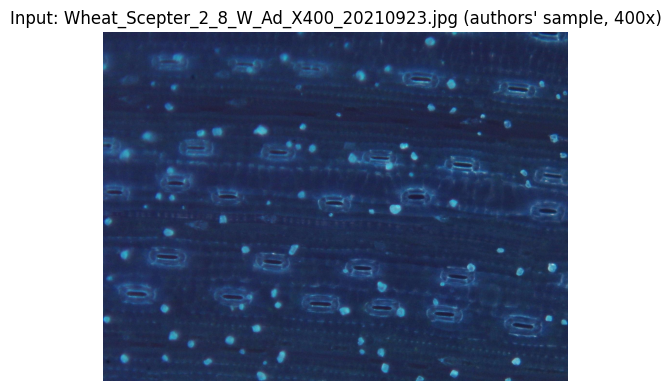

In [ ]:
import cv2, matplotlib.pyplot as plt
IMG_PATH = "/content/sample/Wheat_Scepter_2_8_W_Ad_X400_20210923.jpg"
img_bgr = cv2.imread(IMG_PATH)
assert img_bgr is not None, "sample image failed to load"
print("image shape (H, W, C):", img_bgr.shape)
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title("Input: Wheat_Scepter_2_8_W_Ad_X400_20210923.jpg (authors' sample, 400x)")
plt.axis("off")
plt.show()

## 4. Stomata detection with the author's parameters / 気孔検出

The authors' Wheat Detection (400×) script runs `yolov5/detect.py --img 416 --conf 0.4 --save-txt`. We run the same command on the single sample; each line in the resulting label `.txt` is one detected stoma. / 著者のパラメータ(`--img 416 --conf 0.4 --save-txt`)のまま単一画像へ検出を実行します。

In [ ]:
import glob, os, subprocess
run = subprocess.run(
    ["python", "detect.py",
     "--weights", "/content/models/Wheat_detection_400x.pt.pt",
     "--img", "416", "--conf", "0.4", "--source", IMG_PATH, "--save-txt"],
    cwd="/content/yolov5", capture_output=True, text=True)
print(run.stdout[-3000:])
assert run.returncode == 0, run.stderr[-2000:]
labels = sorted(glob.glob("/content/yolov5/runs/detect/exp*/labels/*.txt"))
assert labels, "no detection label file produced"
LABEL_TXT = labels[-1]
with open(LABEL_TXT) as f:
    dets = [ln.split() for ln in f if ln.strip()]
print(f"Detected stomata: {len(dets)}  (label file: {LABEL_TXT})")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
detect: weights=['/content/models/Wheat_detection_400x.pt.pt'], source=/content/sample/Wheat_Scepter_2_8_W_Ad_X400_20210923.jpg, data=data/coco128.yaml, imgsz=[416, 416], conf_thres=0.4, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-555-g4add2aff Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
custom_YOLOv5s summary: 146 layers, 7,246,518 parameters, 0 gr

## 5. Detection overlay / 検出結果の重ね合わせ

Side-by-side view: original input (left) and YOLOv5 detection overlay produced by `detect.py` (right). Model predictions, not author annotations. / 左が入力画像、右がYOLOv5による検出結果(モデル予測)です。

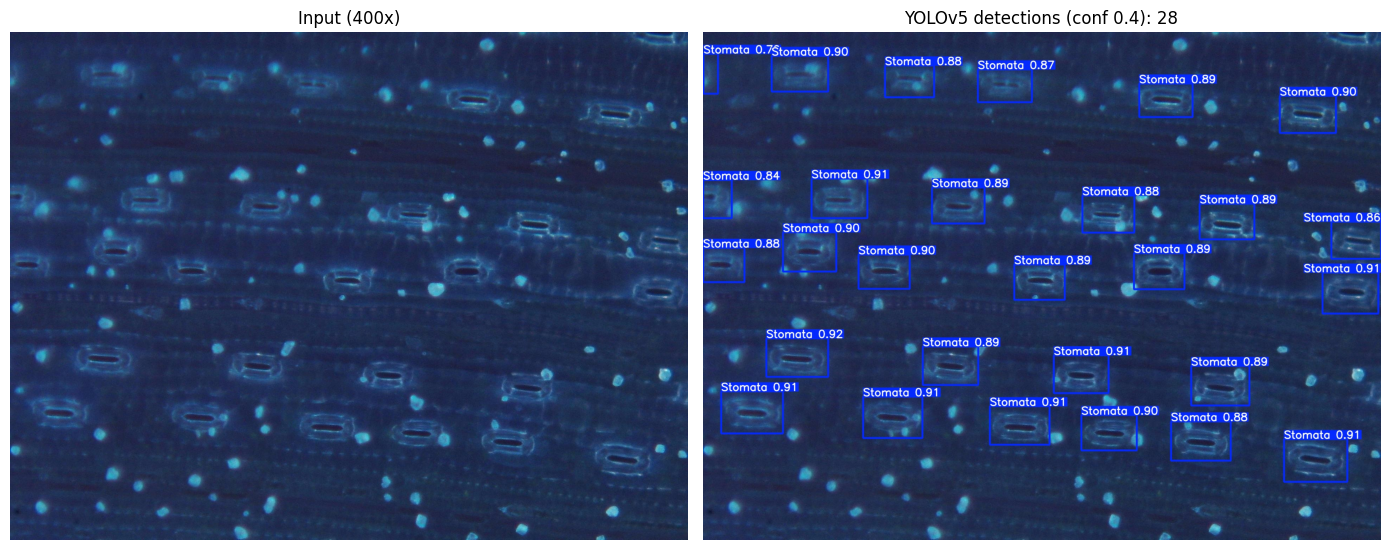

In [ ]:
import matplotlib.pyplot as plt, cv2, glob
exp_dirs = sorted(glob.glob("/content/yolov5/runs/detect/exp*"), key=lambda p: os.path.getmtime(p))
overlay_path = glob.glob(os.path.join(exp_dirs[-1], "*.jpg"))[0]
ov = cv2.imread(overlay_path)
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)); axes[0].set_title("Input (400x)"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(ov, cv2.COLOR_BGR2RGB)); axes[1].set_title(f"YOLOv5 detections (conf 0.4): {len(dets)}"); axes[1].axis("off")
plt.tight_layout(); plt.show()

## 6. Bounding-box extraction (authors' code, verbatim) / 検出枠の切り出し

`ExtractBBox` is copied **verbatim** from the authors' `Bounding_box_extraction.ipynb`: it reads the normalized YOLO label file, converts to pixel coordinates and crops RGB patches. We save them under `/content/stomata_crops/` (the authors saved to `/content/*.png`). / 著者の `ExtractBBox` をそのままコピーし、検出枠ごとにRGBパッチを切り出します。

In [ ]:
import numpy as np
from copy import deepcopy
import cv2

def ExtractBBox(img_path, bbox_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    label = np.loadtxt(bbox_path)
    label = np.reshape(label, [-1, 5])
    h, w, _ = img.shape
    objects = []
    for bbox in label:
        bbox_center_w = int(bbox[1] * w)
        bbox_center_h = int(bbox[2] * h)
        bbox_w = int(bbox[3] * w)
        bbox_h = int(bbox[4] * h)
        cpatch = deepcopy(img[(bbox_center_h - bbox_h//2):(bbox_center_h + bbox_h//2),
                              (bbox_center_w - bbox_w//2):(bbox_center_w + bbox_w//2), :])
        objects.append(cpatch)
    return objects

def save_img(img_path, img):
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    cv2.imwrite(img_path, img)

import os
os.makedirs("/content/stomata_crops", exist_ok=True)
for f in glob.glob("/content/stomata_crops/*.png"):
    os.remove(f)
patches = ExtractBBox(IMG_PATH, LABEL_TXT)
crop_paths = []
for idx, p in enumerate(patches):
    fname = f"/content/stomata_crops/{idx}.png"
    save_img(fname, p)
    crop_paths.append(fname)
print(f"Extracted {len(crop_paths)} stomata crops")

Extracted 28 stomata crops


Preview of the extracted individual stomata (model-detected boxes, cropped from the sample). / 切り出された個々の気孔画像のプレビュー。

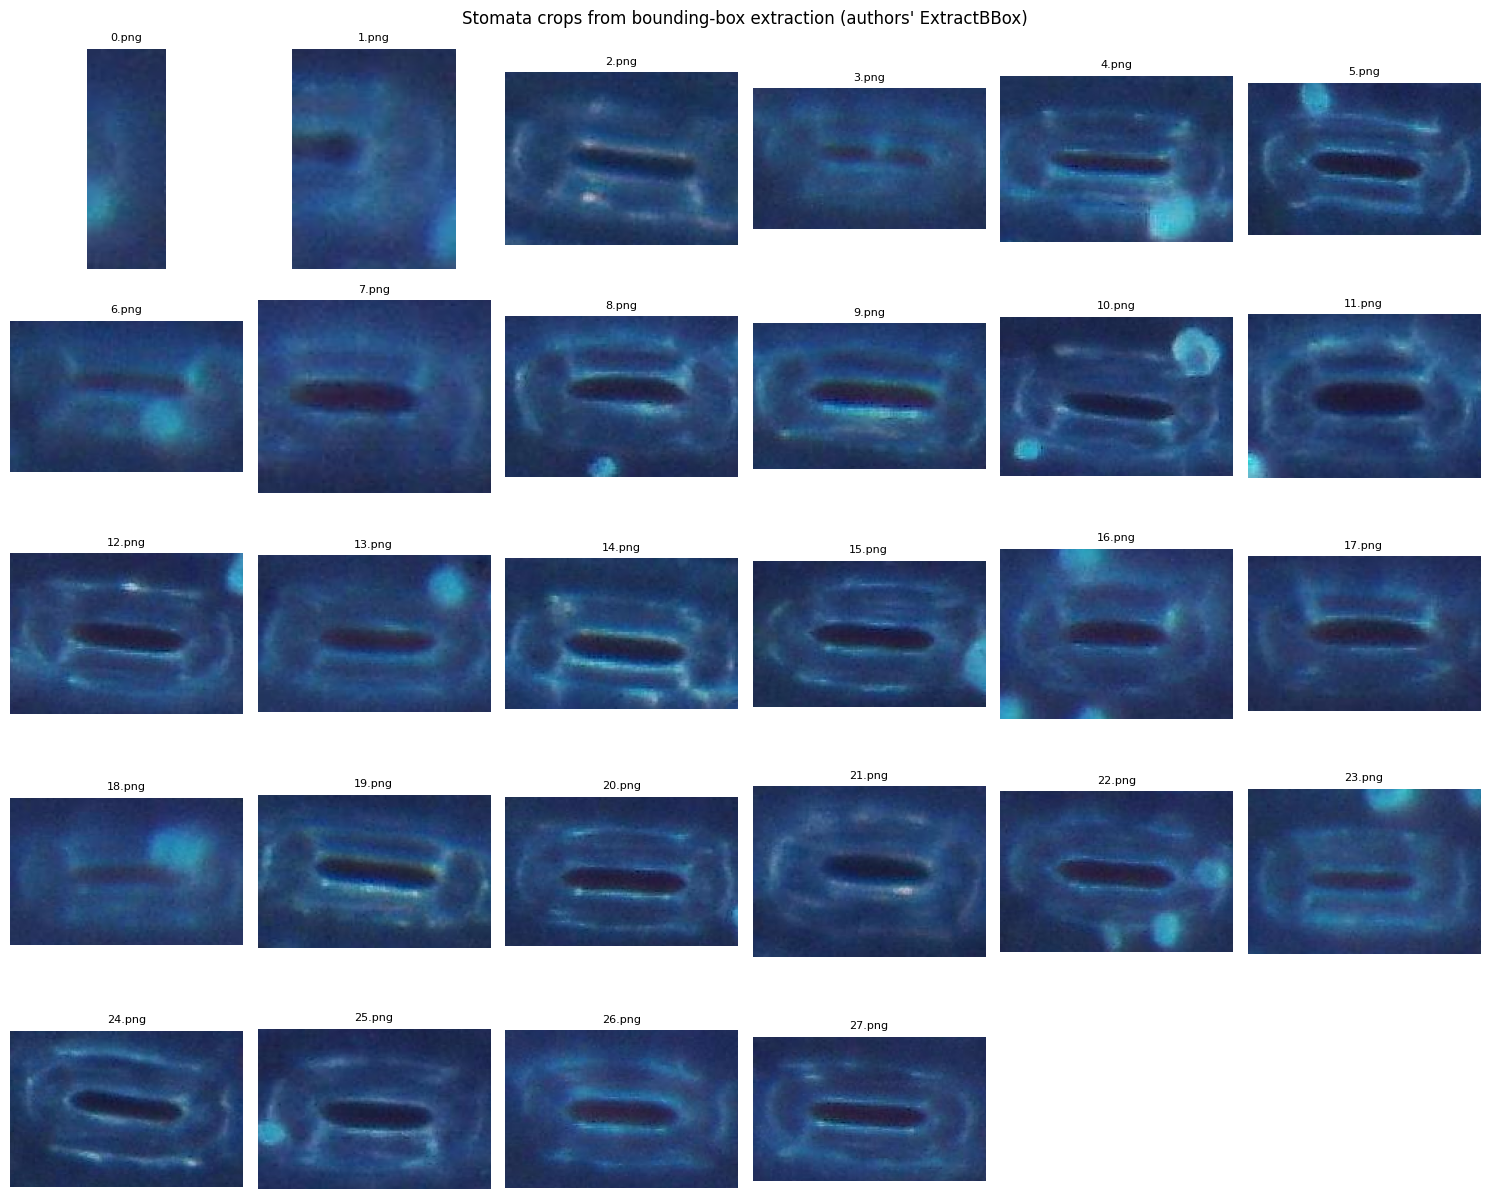

In [ ]:
n = len(crop_paths)
cols = min(6, max(1, n))
rows = (n + cols - 1) // cols
plt.figure(figsize=(2.5 * cols, 2.5 * rows))
for i, cp in enumerate(crop_paths):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(cv2.cvtColor(cv2.imread(cp), cv2.COLOR_BGR2RGB))
    plt.title(os.path.basename(cp), fontsize=8)
    plt.axis("off")
plt.suptitle("Stomata crops from bounding-box extraction (authors' ExtractBBox)")
plt.tight_layout(); plt.show()

## 7. Measurement model: Detectron2 (authors' configuration) / 計測モデル(Detectron2)

The authors' Wheat Measurement (400×) script installs Detectron2 at their pinned commit and configures Mask R-CNN R_50_FPN_3x with `NUM_CLASSES=27` and `SCORE_THRESH_TEST=0.6`, loading `Wheat_measurement.pth`. The pinned 2022 code needs a one-line Pillow compatibility shim (`PIL.Image.LINEAR` alias); if the pinned build still fails a functional import on the current Colab stack, we fall back to the current Detectron2 master (same Mask R-CNN inference semantics; documented adaptation). / 著者指定のDetectron2コミットを優先し、Pillow互換シムを適用します。それでも機能しない場合のみ現行版へフォールバックします(適応は明記)。

In [ ]:
import subprocess, sys, importlib

def _purge_detectron2():
    for m in list(sys.modules):
        if m == "detectron2" or m.startswith("detectron2."):
            del sys.modules[m]

def _functional_import():
    try:
        from detectron2 import model_zoo  # noqa: F401  (exercises the full import graph)
        import detectron2
        return detectron2.__version__
    except Exception as e:
        print("detectron2 functional import failed:", repr(e)[:300])
        return None

if _functional_import() is None:
    print("Installing authors' pinned detectron2 (5aeb252b...)")
    r = subprocess.run(["pip", "install", "-q",
        "git+https://github.com/facebookresearch/detectron2.git@5aeb252b194b93dc2879b4ac34bc51a31b5aee13"],
        capture_output=True, text=True)
    print("pinned build rc:", r.returncode, r.stderr[-400:] if r.returncode else "")
    import PIL.Image
    if not hasattr(PIL.Image, "LINEAR"):
        # Compat shim: the authors' pinned detectron2 uses the Pillow alias removed in Pillow>=10.
        PIL.Image.LINEAR = PIL.Image.Resampling.BILINEAR
    _purge_detectron2()

if _functional_import() is None:
    print("Falling back to current detectron2 master (documented adaptation)")
    r = subprocess.run(["pip", "install", "-q", "--force-reinstall", "--no-deps",
        "git+https://github.com/facebookresearch/detectron2.git"],
        capture_output=True, text=True)
    assert r.returncode == 0, r.stderr[-1500:]
    _purge_detectron2()

_ver = _functional_import()
assert _ver, "detectron2 could not be installed"
print("detectron2", _ver)

detectron2 functional import failed: ModuleNotFoundError("No module named 'detectron2'")
Installing authors' pinned detectron2 (5aeb252b...)


pinned build rc: 0 


/usr/local/lib/python3.13/dist-packages/detectron2/model_zoo/model_zoo.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


detectron2 0.6


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Below is the authors' configuration cell with values kept verbatim (`NUM_CLASSES=27`, `SCORE_THRESH_TEST=0.6`); only `cfg.MODEL.WEIGHTS` points to the locally downloaded copy of `Wheat_measurement.pth`, and the device follows the allocated runtime. / 著者の設定値をそのまま用い、重みパスとデバイスのみ環境に合わせます。

In [ ]:
# Authors' config, verbatim values; only the weights path is adapted to the local download.
import torch, cv2, numpy as np
import PIL.Image
if not hasattr(PIL.Image, "LINEAR"):  # compat shim for the authors' pinned detectron2
    PIL.Image.LINEAR = PIL.Image.Resampling.BILINEAR
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer, ColorMode

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.WEIGHTS = "/content/models/Wheat_measurement.pth"   # authors' Wheat_measurement.pth
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 512
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 27        # authors' value (26 letters plus one super class)
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.6 # authors' testing threshold
if DEVICE == "cpu":
    cfg.MODEL.DEVICE = "cpu"
pred = DefaultPredictor(cfg)
print("DefaultPredictor ready on", cfg.MODEL.DEVICE)

DefaultPredictor ready on cuda


## 8. Stomata measurement on the extracted crops / 個体ごとの面積測定

The authors' measurement loop runs the predictor on each crop and records **mask pixel area**: class 2 → `Stomata Area (pixel)`, other classes → `Aperture Area (pixel)`; crops without exactly one stoma detection are skipped (authors' rule). Areas are in **pixels** (the released scripts include no µm calibration). / 著者のルールに従い、各切り出し画像のマスク面積(ピクセル)を記録します(クラス2を気孔、それ以外を開孔部とみなす)。

In [ ]:
import pandas as pd
rows = []
vis_outputs = []
for cp in crop_paths:
    inputs = cv2.imread(cp)  # BGR, as in the authors' loop
    outputs = pred(inputs)
    inst = outputs["instances"].to("cpu")
    classes = inst.pred_classes.cpu()
    masks = inst.pred_masks.cpu()
    try:
        nsize = masks.view(masks.shape[0], -1).float().sum(1)
    except Exception:
        continue
    num_stomata = 0
    cres = {"File Name": os.path.basename(cp)[:-4], "Aperture Area (pixel)": 0}
    for idx in range(classes.shape[0]):
        if classes[idx].item() == 2:
            num_stomata += 1
            cres["Stomata Area (pixel)"] = nsize[idx].item()
        else:
            cres["Aperture Area (pixel)"] = nsize[idx].item()
    if num_stomata != 1:
        print(f"skip {cres['File Name']}: {num_stomata} stoma detections")
        continue
    rows.append(cres)
    vis_outputs.append((cp, inst))
all_res_df = pd.DataFrame(rows)
assert len(all_res_df) > 0, "no crop produced exactly one stoma detection; measurement table empty"
print(all_res_df.to_string(index=False))

/usr/local/lib/python3.13/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


File Name  Aperture Area (pixel)  Stomata Area (pixel)
        1                    0.0                5906.0
        2                 1269.0                7859.0
        3                    0.0                8275.0
        4                  956.0                9133.0
        5                 1413.0                9531.0
        6                    0.0                7212.0
        7                 1002.0                6641.0
        8                 1213.0                8164.0
        9                    0.0                8915.0
       10                 1274.0               10657.0
       11                    0.0                8162.0
       12                 1322.0                9180.0
       13                    0.0                9421.0
       14                 1515.0                9562.0
       15                 1345.0                8921.0
       16                  969.0                9998.0
       17                 1255.0                8022.0
       18 

Visualization of the measurement predictions (stomata mask + aperture mask per crop, Detectron2 `Visualizer` with the authors' `ColorMode.IMAGE_BW`). / 各切り出し画像のセグメンテーション予測を可視化します。

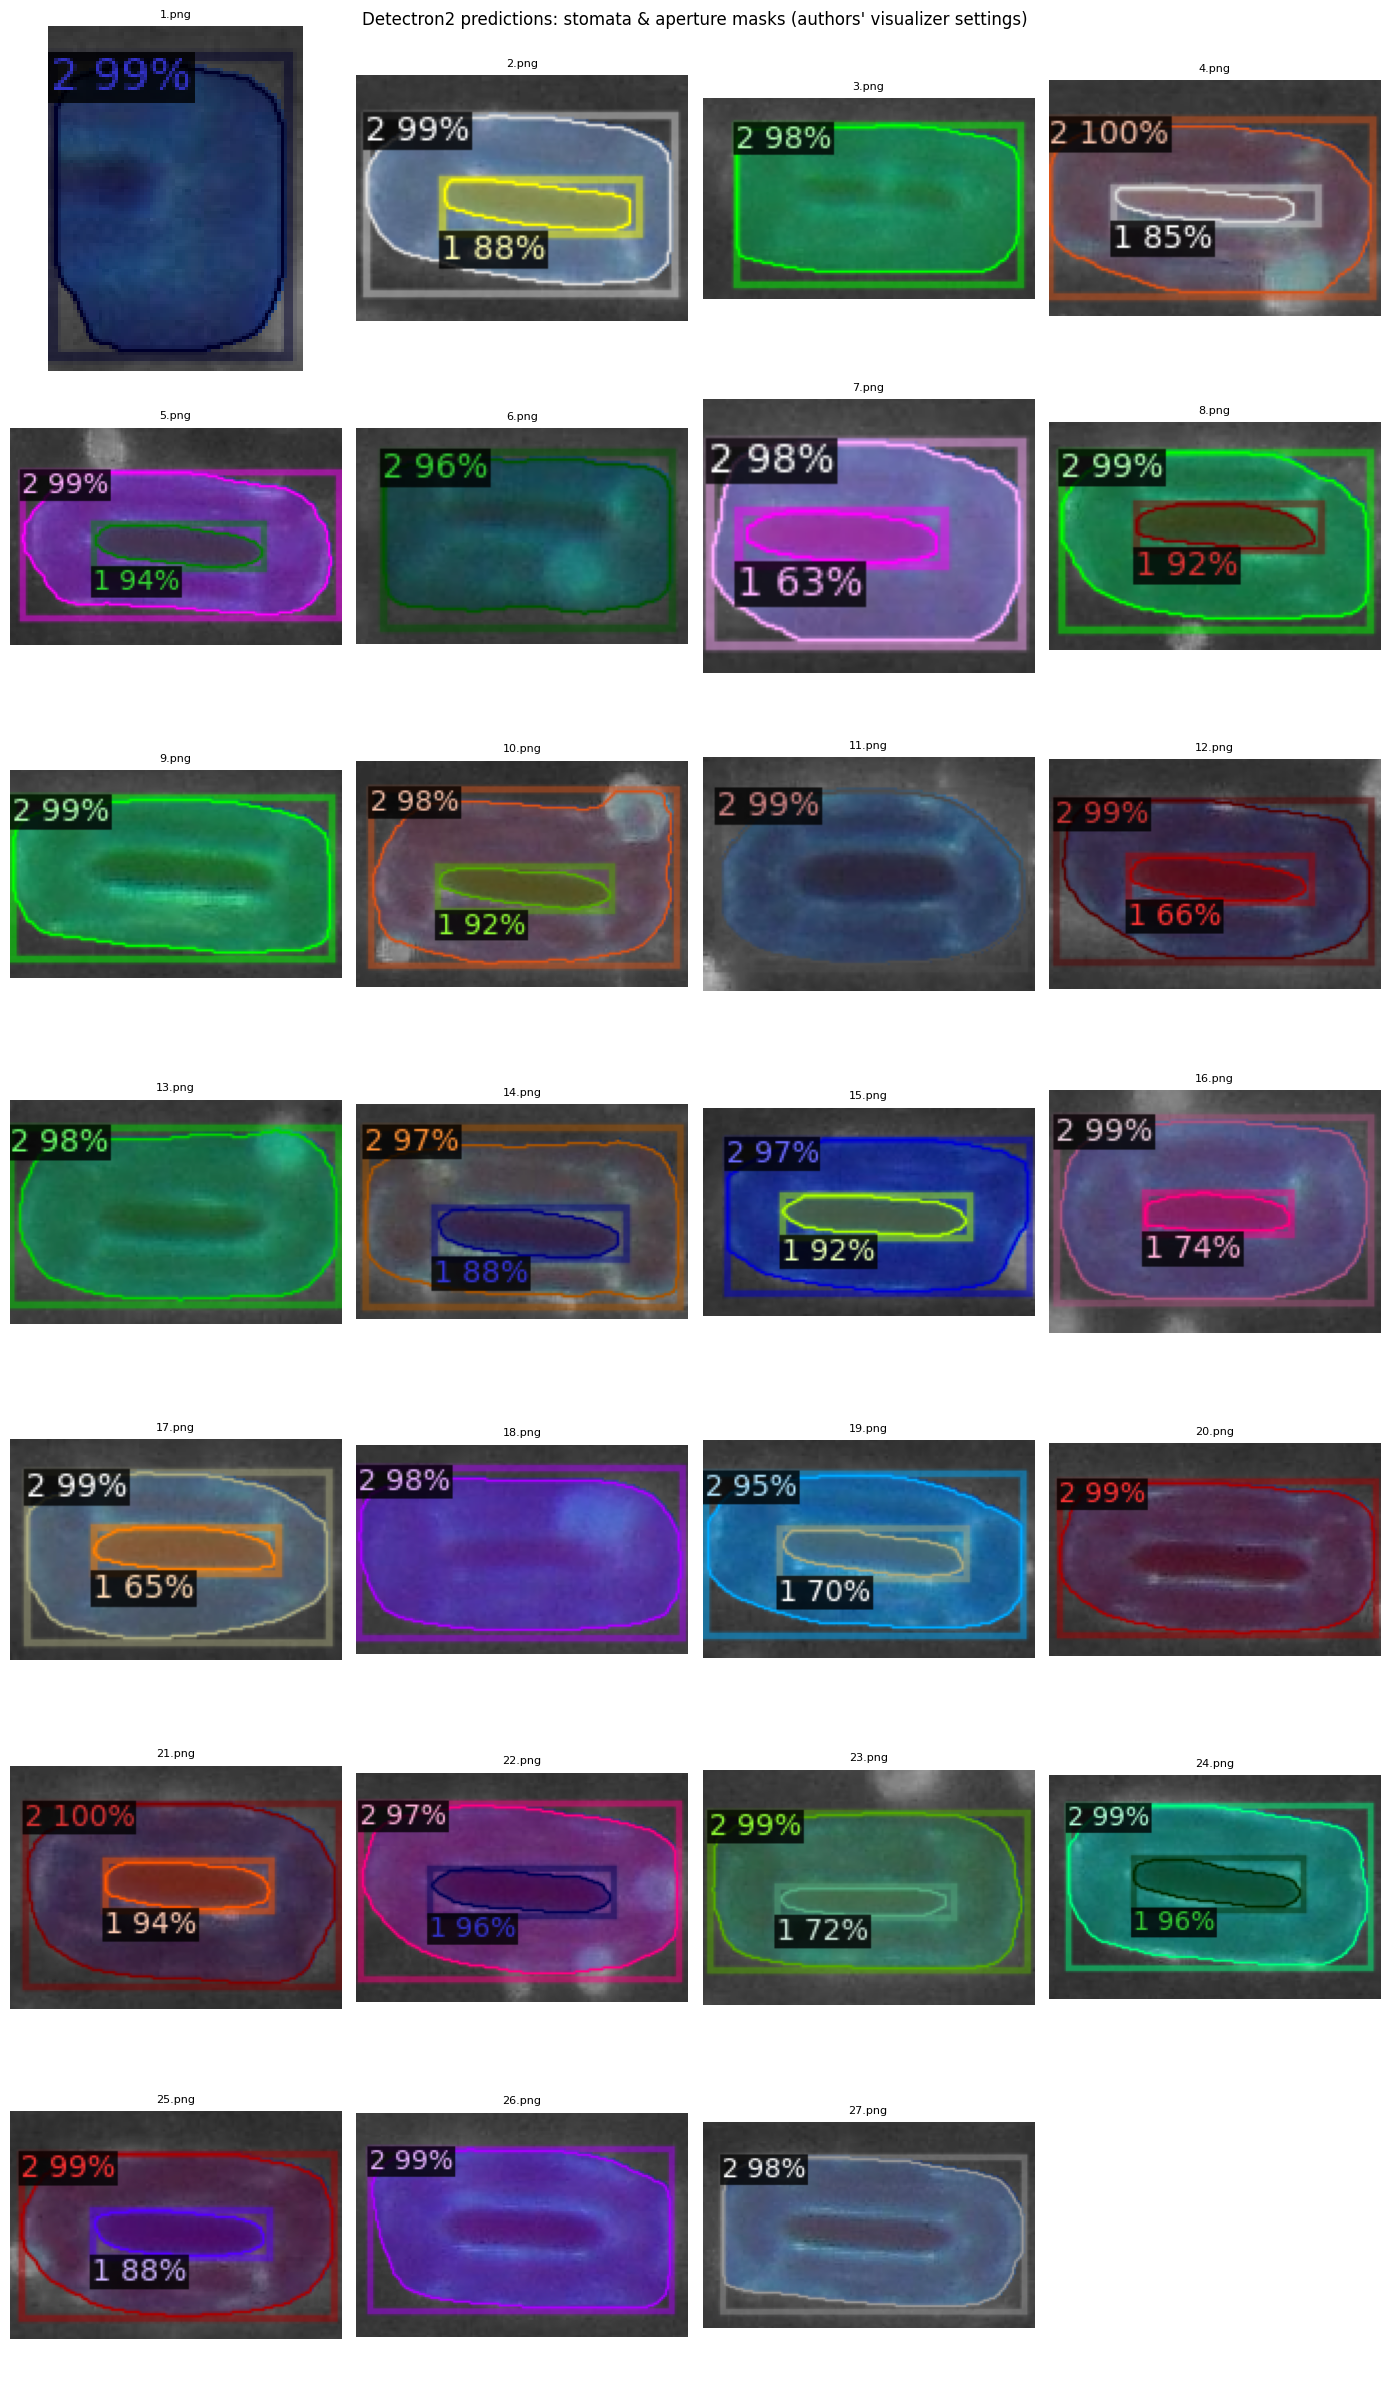

In [ ]:
from detectron2.utils.visualizer import Visualizer, ColorMode
ncrop = len(vis_outputs)
cols = min(4, max(1, ncrop))
rows = (ncrop + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3.5 * cols, 3.5 * rows), squeeze=False)
for k, (cp, inst) in enumerate(vis_outputs):
    v = Visualizer(cv2.imread(cp)[:, :, ::-1], instance_mode=ColorMode.IMAGE_BW)
    out = v.draw_instance_predictions(inst)
    ax = axes[k // cols][k % cols]
    ax.imshow(out.get_image())
    ax.set_title(os.path.basename(cp), fontsize=8)
    ax.axis("off")
for k in range(ncrop, rows * cols):
    axes[k // cols][k % cols].axis("off")
plt.suptitle("Detectron2 predictions: stomata & aperture masks (authors' visualizer settings)")
plt.tight_layout(); plt.show()

## 9. Results export / 結果の保存

Small results table (stomata count from detection; per-stoma pixel areas from measurement) and CSV export, mirroring the authors' `res.csv`. / 検出数と面積の一覧表を表示し、`res.csv` として保存します。

In [ ]:
summary = {
    "sample_image": os.path.basename(IMG_PATH),
    "device": DEVICE,
    "detected_stomata": len(dets),
    "crops_measured": len(all_res_df),
}
print(summary)
all_res_df.to_csv("/content/res.csv", index=False)
display(all_res_df)

{'sample_image': 'Wheat_Scepter_2_8_W_Ad_X400_20210923.jpg', 'device': 'cuda', 'detected_stomata': 28, 'crops_measured': 27}


,File Name,Aperture Area (pixel),Stomata Area (pixel)
0,1,0.0,5906.0
1,2,1269.0,7859.0
2,3,0.0,8275.0
3,4,956.0,9133.0
4,5,1413.0,9531.0
5,6,0.0,7212.0
6,7,1002.0,6641.0
7,8,1213.0,8164.0
8,9,0.0,8915.0
9,10,1274.0,10657.0


## 10. Interpretation & limitations / 解釈と限界

- This run exercises the **authors' released Wheat 400× inference pipeline** on one sample: detection count and per-stoma area (pixels) are the pipeline's actual outputs.
- The paper's validation statistics (e.g., wheat R² = 0.99 stomata number, 0.87 size, 0.94 aperture vs manual Fiji measurements) are dataset-level results and are **not** reproduced by a single-image run.
- Areas are in pixels; the released scripts include no µm² calibration, so no physical-unit conversion is claimed.
- YOLOv5/Detectron2 versions were pinned to current revisions for reproducibility; author parameters (`--img 416 --conf 0.4`, Mask R-CNN R50-FPN 3x, score threshold 0.6, class-2 = stomata) are preserved.
- No author reference output exists for this exact image, so results are plausibility checks, not quantitative equivalence tests.

**References:** Pathoumthong et al. 2023, Plant Methods 19:36 (DOI 10.1186/s13007-023-01016-y); code `rapidmethodstomata/rapidmethodstomata` @ `a8ff03832b9e03b03c55c1ff3a08f7244f8a1e85`; models/samples from the authors' public Drive folder. YOLOv5 by Ultralytics; Detectron2 by Facebook AI Research (Apache-2.0).